# PHASE 1: IMPORTS, DATA CLEANING & FEATURE SELECTION

In [25]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

In [26]:
# 1. Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

In [27]:
#2. Drop the "Noise" and "Bias" Features (Based on our correlation math)
cols_to_drop = [
    'Employee_ID', 'Region', 'Age', 'Gender',
    'Industry', 'Job_Role', 'Years_of_Experience'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [28]:
df

,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality
0,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good
1,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good
2,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor
3,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor
4,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Onsite,24,2,5,High,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average
4996,Onsite,48,15,1,Low,Depression,Yes,Decrease,1,Satisfied,1,NaN,Average
4997,Hybrid,34,1,4,High,Burnout,No,Increase,3,Satisfied,1,Daily,Poor
4998,Remote,58,0,5,Low,NaN,Yes,Increase,3,Unsatisfied,4,Daily,Average


In [29]:
df.isnull().sum()

Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
dtype: int64

In [30]:
# 3. Handle Missing Values
df['Physical_Activity'] = df['Physical_Activity'].fillna('Unknown')
df['Mental_Health_Condition'] = df['Mental_Health_Condition'].fillna('Healthy')

In [31]:
# 4. Apply the realistic behavioral logic to the target
def apply_fine_tuned_logic(row):
    if random.random() < 0.05: # 5% random noise for realism
        return random.choice(['Anxiety', 'Burnout', 'Depression', 'Healthy'])

    if row['Stress_Level'] == 'High' and row['Hours_Worked_Per_Week'] >= 45:
        return 'Burnout'
    elif row['Social_Isolation_Rating'] >= 4:
        return 'Depression'
    elif row['Work_Life_Balance_Rating'] <= 2:
        return 'Anxiety'
    else:
        return 'Healthy'

df['Mental_Health_Condition'] = df.apply(apply_fine_tuned_logic, axis=1)
print(f"Data Cleaned. Final Shape: {df.shape}")

Data Cleaned. Final Shape: (5000, 13)


#Phase 2: Translation, Splitting & SMOTE Balancing

In [32]:
# 1. Separate Features (X) and Target (y)
X = df.drop('Mental_Health_Condition', axis=1)
y = df['Mental_Health_Condition']

In [33]:
# 2. Translation (Encoding)
X_encoded = pd.get_dummies(X, drop_first=True) # Text to 1s and 0s
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Text to 0, 1, 2, 3

In [34]:
# 3. The 80/20 Split (With Stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)

In [35]:
print("\n[PROOF] EXACT NUMBERS BEFORE SMOTE:")
print(pd.Series(le.inverse_transform(y_train)).value_counts())



[PROOF] EXACT NUMBERS BEFORE SMOTE:
Depression    1358
Healthy       1243
Anxiety        858
Burnout        541
Name: count, dtype: int64


In [36]:
# Apply SMOTE strictly to Training Data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [37]:
print("\n[PROOF] EXACT NUMBERS AFTER SMOTE:")
print(pd.Series(le.inverse_transform(y_train_balanced)).value_counts())


[PROOF] EXACT NUMBERS AFTER SMOTE:
Healthy       1358
Burnout       1358
Depression    1358
Anxiety       1358
Name: count, dtype: int64


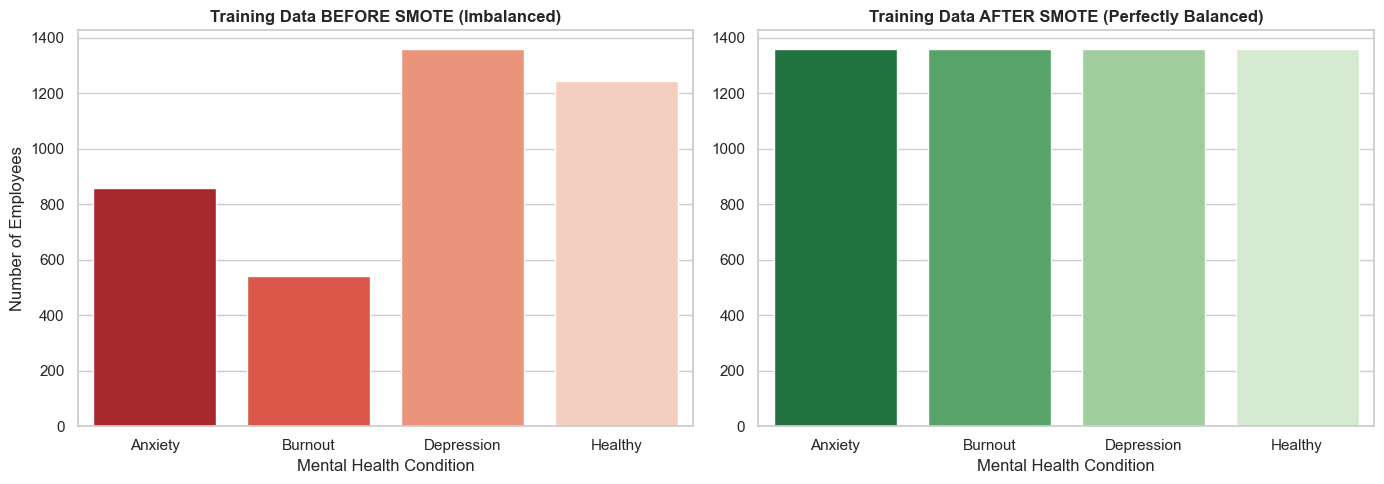

In [38]:
# --- VISUALIZATION 1: PROVE DATA BALANCE (BEFORE VS AFTER SMOTE) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Imbalanced Data (Before)
sns.countplot(x=le.inverse_transform(y_train), ax=axes[0], palette='Reds_r', order=le.classes_)
axes[0].set_title('Training Data BEFORE SMOTE (Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
axes[0].set_xlabel('Mental Health Condition')

# Chart 2: Balanced Data (After)
sns.countplot(x=le.inverse_transform(y_train_balanced), ax=axes[1], palette='Greens_r', order=le.classes_)
axes[1].set_title('Training Data AFTER SMOTE (Perfectly Balanced)', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Mental Health Condition')
plt.tight_layout()
plt.show()

#Phase 3: The Model Tournament & Final Evaluation

In [39]:
results = []

# Helper function to print live results and store them
def print_and_store_metrics(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n {model_name} Training Complete!")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

In [40]:
# 1. Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)
lr_preds = lr_model.predict(X_test)
results.append(print_and_store_metrics('Logistic Regression', y_test, lr_preds))

Training Logistic Regression...

 Logistic Regression Training Complete!
   Accuracy  : 0.9240
   Precision : 0.9242
   Recall    : 0.9240
   F1-Score  : 0.9240


In [41]:
# 2. Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_preds = rf_model.predict(X_test)
results.append(print_and_store_metrics('Random Forest', y_test, rf_preds))

Training Random Forest...

 Random Forest Training Complete!
   Accuracy  : 0.9760
   Precision : 0.9763
   Recall    : 0.9760
   F1-Score  : 0.9760


In [42]:
# 3. Train XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42)
xgb_model.fit(X_train_balanced, y_train_balanced)
xgb_preds = xgb_model.predict(X_test)
results.append(print_and_store_metrics('XGBoost', y_test, xgb_preds))

Training XGBoost...

 XGBoost Training Complete!
   Accuracy  : 0.9710
   Precision : 0.9714
   Recall    : 0.9710
   F1-Score  : 0.9709


In [43]:
print("------Comparision of each Model------\n")
results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

------Comparision of each Model------

              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.924     0.9242   0.924    0.9240
      Random Forest     0.976     0.9763   0.976    0.9760
            XGBoost     0.971     0.9714   0.971    0.9709


#PHASE 4: FINAL EVALUATION & VISUALIZATIONS

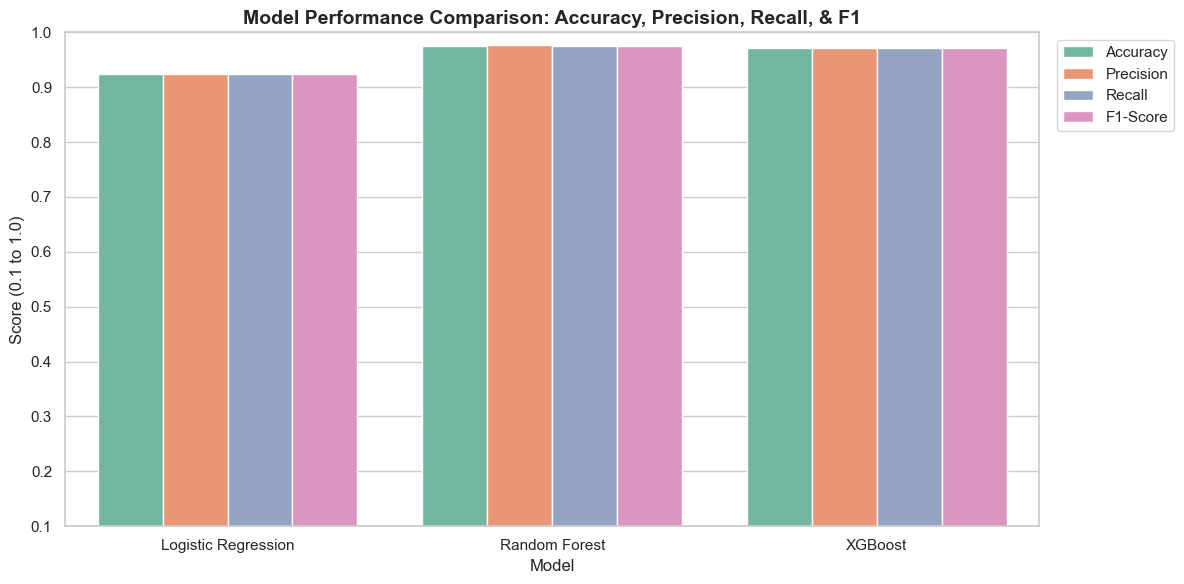

In [44]:
# 2. VISUALIZATION: Grouped Bar Chart of All 4 Metrics
# We 'melt' the dataframe to make it easy for Seaborn to plot side-by-side bars
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison: Accuracy, Precision, Recall, & F1', fontweight='bold', fontsize=14)
plt.ylim(0.1, 1) # Set limits from 0.1 to 1 for a clean look
plt.ylabel('Score (0.1 to 1.0)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') # Move legend outside the chart
plt.tight_layout()
plt.show()

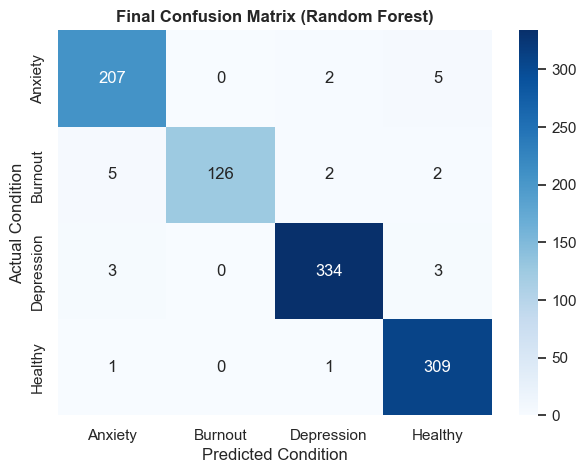

In [45]:
# 3. VISUALIZATION: Confusion Matrix (For the best model, Random Forest)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Confusion Matrix (Random Forest)', fontweight='bold')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()

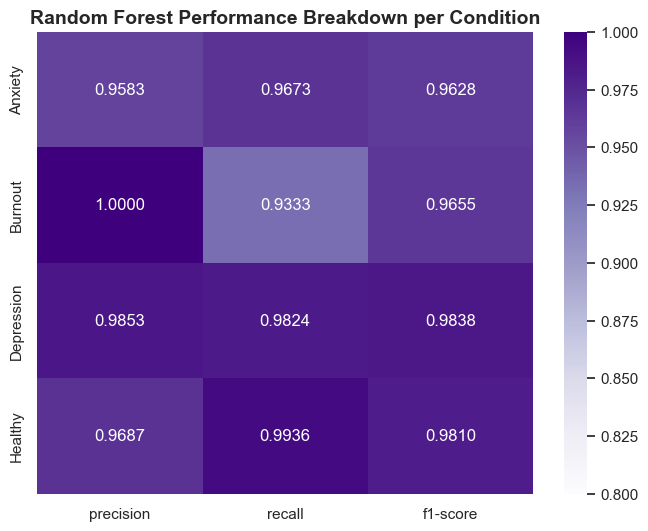

In [46]:
from sklearn.metrics import classification_report
# Generate the report as a dictionary
report = classification_report(y_test, rf_preds, target_names=le.classes_, output_dict=True)

# Convert to DataFrame and drop the 'support' row to keep the heat map clean
report_df = pd.DataFrame(report).iloc[:-1, :4].T

plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, cmap='Purples', fmt='.4f', vmin=0.8, vmax=1.0)
plt.title('Random Forest Performance Breakdown per Condition', fontweight='bold', fontsize=14)
plt.show()

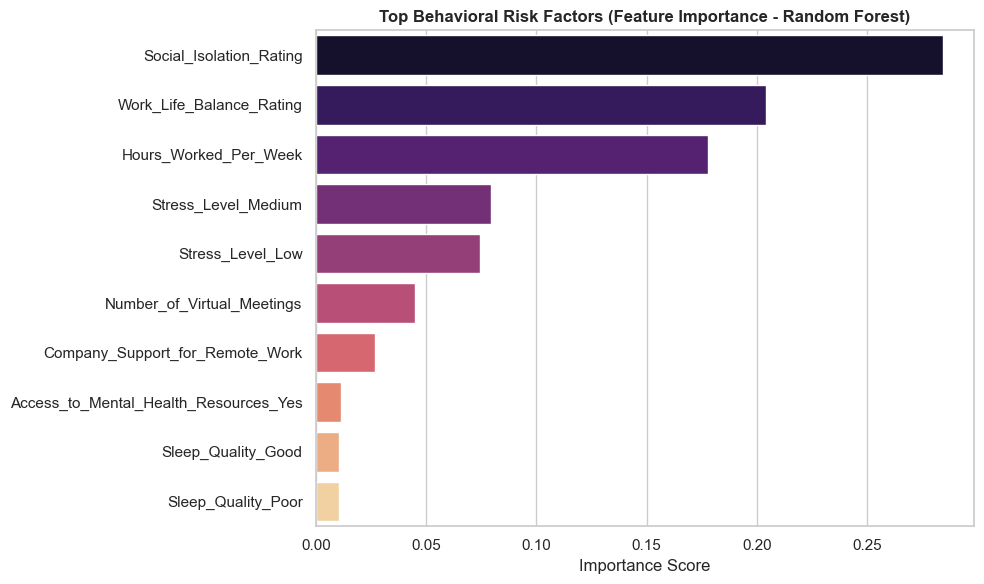

In [47]:
# --- VISUALIZATION 4: Feature Importance (Random Forest) ---
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train_balanced.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')
plt.title('Top Behavioral Risk Factors (Feature Importance - Random Forest)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

#Phase 5: Exporting the Model for Deployment

In [48]:
joblib.dump(rf_model, 'mental_health_rf_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(list(X_train_balanced.columns), 'expected_columns.pkl')

print("PROJECT COMPLETE! Files successfully saved:")
print("1. mental_health_rf_model.pkl (The Trained AI)")
print("2. label_encoder.pkl (The Condition Translator)")
print("3. expected_columns.pkl (The Map for Web Deployment)")

PROJECT COMPLETE! Files successfully saved:
1. mental_health_rf_model.pkl (The Trained AI)
2. label_encoder.pkl (The Condition Translator)
3. expected_columns.pkl (The Map for Web Deployment)
